# FEATURE ENGINEERING

In this notebook I will cover the feature engineering aspect of the project. This will include:
- Balance drain ratio
- Cyclical time encoding
- Derived behavioural features documented with rationale

In [28]:
# Library Importation
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [29]:
# data loading
df = pd.read_csv('../Data/mpesa_synthetic.csv')
df.head()

,transaction_id,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,transaction_type,hour,month_2026,day_of_week,device_type,region,is_fraud
0,UA0IFD0TV,703.90,58586.32,57882.42,29932.92,30636.82,peer,14,1,Tuesday,smartphone,Nairobi,0
1,UJAHXTHV3,254.44,8088.00,7833.56,22962.44,23216.88,peer,18,10,Saturday,feature,Eldoret,1
2,UEF8MDD4V,609.04,56675.00,56065.96,1029.22,1638.26,till,7,5,Thursday,smartphone,Kisumu,0
3,UBT3W5UZB,5255.34,75090.36,69835.02,38.94,5294.28,paybill,11,2,Monday,smartphone,Nakuru,0
4,UGKWNNHJ7,7282.67,24408.96,17126.29,26237.82,33520.49,till,0,7,Saturday,smartphone,Nairobi,0


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           120000 non-null  str    
 1   amount                   120000 non-null  float64
 2   sender_balance_before    120000 non-null  float64
 3   sender_balance_after     120000 non-null  float64
 4   receiver_balance_before  120000 non-null  float64
 5   receiver_balance_after   120000 non-null  float64
 6   transaction_type         120000 non-null  str    
 7   hour                     120000 non-null  int64  
 8   month_2026               120000 non-null  int64  
 9   day_of_week              120000 non-null  str    
 10  device_type              120000 non-null  str    
 11  region                   120000 non-null  str    
 12  is_fraud                 120000 non-null  int64  
dtypes: float64(5), int64(3), str(5)
memory usage: 11.9 MB


In [31]:
zero_transactions = df[df['amount'] == 0]
zero_transactions

,transaction_id,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,transaction_type,hour,month_2026,day_of_week,device_type,region,is_fraud
84990,UDSI0IDKI,0.0,5827.75,5827.75,23707.86,23707.86,peer,19,4,Sunday,feature,Eldoret,0


In [32]:
# Droping the zero transaction entry
df = df.drop(zero_transactions.index)
df.shape

(119999, 13)

In [33]:
#Mapping day of week to number
# craeting a function to map all entries in the day of week column
mapper = {
    'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4,
    'Friday': 5, 'Saturday': 6, 'Sunday': 7
}

df['day'] = df['day_of_week'].map(mapper)
df['day'].value_counts()

day
1    17408
5    17339
7    17189
6    17142
2    17110
3    16989
4    16822
Name: count, dtype: int64

In [34]:
# Mapping is_farud to transaction_status(Labled class category)
def status_mapp(status):
    if status == 0:
        return 'LEGITIMATE'
    else:
        return 'FRAUD'

df['transaction_status'] = df['is_fraud'].apply(lambda x: status_mapp(x))
df['transaction_status'].value_counts()

transaction_status
LEGITIMATE    116489
FRAUD           3510
Name: count, dtype: int64

In [35]:
under_1 = df[df['amount'] < 1]
under_1.shape

(84, 15)

In [36]:
fraud_under1 = under_1[under_1['transaction_status'] == 'FRAUD']
fraud_under1.shape

(2, 15)

In [37]:
# Droping transactions below KES 1
df = df.drop(under_1.index)
df.shape

(119915, 15)

> The reason as to why I droped transactions below **KES 1** is because in a real world setting the minimum transactable amount is **KES 1**. The final deployed model should be able to perform in real world settings and training it with impossible noise only overfits the model for no reason.

## Cyclic Encoding

- I will be targeting the temporal data so that I ensure there is continuity and time refrence. It will also help the model understand that even though hour 0 and hour 23 are 23 steps away linearly in they are only a step away from each other in time.
- Using the formulas:
     - `cos(2π * value/max_value)` 
     - `sin(2π * value/max_value)`
- The **max_value** will be the number of steps to complete a single cycle
- For every temporal column we will have 2 columns eg for the 'hour' column we will have '**hour_sin**' and **'hour_cos'**

In [38]:
# Deine a cyclic encoding function
def cyclic_encoder(column_name, max_val):
   df[column_name + '_sin'] = df[column_name].apply(lambda x: np.sin(2*np.pi*x/max_val))
   df[column_name + '_cos'] = df[column_name].apply(lambda x: np.cos(2*np.pi*x/max_val))
   return df

# call the function to our 3 columns:
cyclic_encoder('hour', 24)
cyclic_encoder('day', 7)
cyclic_encoder('month_2026', 12)

df.shape

(119915, 21)

In [39]:
print(df.head())

  transaction_id   amount  sender_balance_before  sender_balance_after  \
0      UA0IFD0TV   703.90               58586.32              57882.42   
1      UJAHXTHV3   254.44                8088.00               7833.56   
2      UEF8MDD4V   609.04               56675.00              56065.96   
3      UBT3W5UZB  5255.34               75090.36              69835.02   
4      UGKWNNHJ7  7282.67               24408.96              17126.29   

   receiver_balance_before  receiver_balance_after transaction_type  hour  \
0                 29932.92                30636.82             peer    14   
1                 22962.44                23216.88             peer    18   
2                  1029.22                 1638.26             till     7   
3                    38.94                 5294.28          paybill    11   
4                 26237.82                33520.49             till     0   

   month_2026 day_of_week  ...   region is_fraud  day  transaction_status  \
0           1  

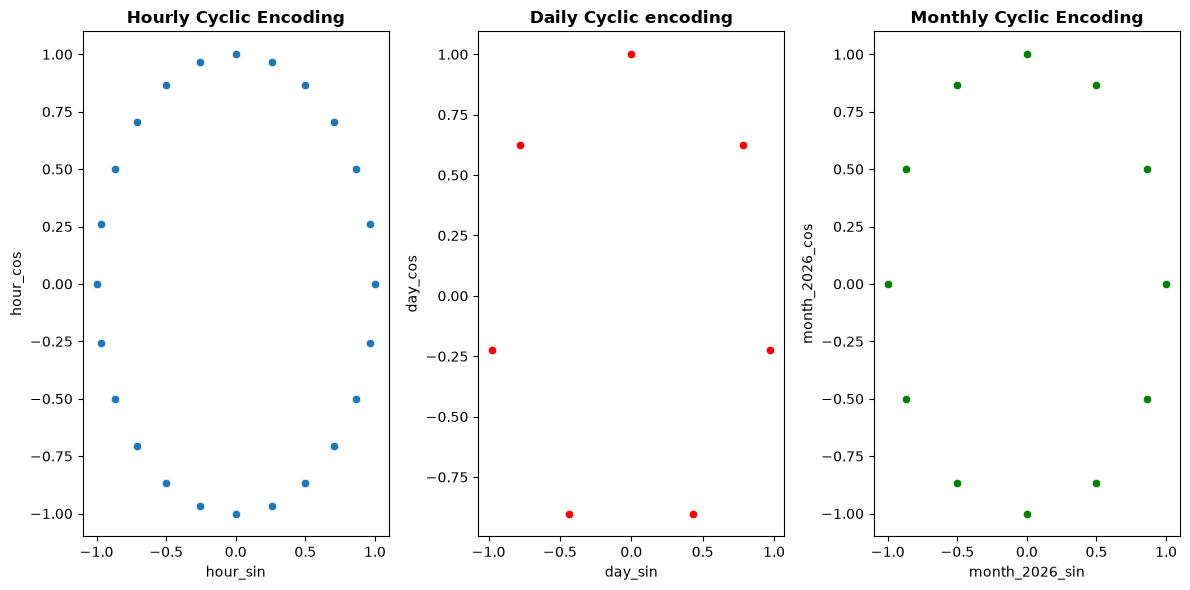

In [40]:
# Visual of all points for the cyclic encoding
fig, axes = plt.subplots(1,3, figsize= (12, 6))

sns.scatterplot(data= df, x = 'hour_sin', y = 'hour_cos', ax=axes[0])
axes[0].set_title('Hourly Cyclic Encoding', weight = 'bold')

sns.scatterplot(data = df, x = 'day_sin', y = 'day_cos', color = 'red', ax=axes[1])
axes[1].set_title('Daily Cyclic encoding', weight = 'bold')

sns.scatterplot(data = df, x = 'month_2026_sin', y = 'month_2026_cos', color = 'green', ax=axes[2])
axes[2].set_title('Monthly Cyclic Encoding', weight = 'bold')

plt.tight_layout()
plt.show()


In [41]:
# Drain rate feature
df['drain_rate'] = (df['amount']/df['sender_balance_before']) * 100
df['drain_rate'].head()



0     1.201475
1     3.145895
2     1.074618
3     6.998688
4    29.836052
Name: drain_rate, dtype: float64

In [42]:
for col in df.columns:
    print(col)
    
print(f'=' * 30)
print(len(df.columns))

transaction_id
amount
sender_balance_before
sender_balance_after
receiver_balance_before
receiver_balance_after
transaction_type
hour
month_2026
day_of_week
device_type
region
is_fraud
day
transaction_status
hour_sin
hour_cos
day_sin
day_cos
month_2026_sin
month_2026_cos
drain_rate
22


In [53]:
# Mapp it the account is emptied or not
df['account_emptied'] = df['amount'] >= df['sender_balance_before']

# Assign int type to it(1 if True, 0 if False)
df['account_emptied'] = df['account_emptied'].map({True: 1, False: 0})
df['account_emptied'].value_counts()

account_emptied
0    117844
1      2071
Name: count, dtype: int64

In [54]:
# Saving to data folder
df.to_csv('../Data/Feature_engineered.csv')

In [ ]:
#Droping_columns
df_modeling = df.drop(columns = ['transaction_id', 'sender_balance_after', 'receiver_balance_before',
                                'receiver_balance_after', 'hour', 'month_2026', 'day_of_week' 'day',
                                'transaction_status'])



### Spliting Evaluation and Training data Sets

In [59]:
# Import train test split from sklearn
from sklearn.model_selection import train_test_split

train_df, eval_df = train_test_split(df, test_size = 10000, random_state=42, stratify=df['is_fraud'])
train_df.head()

,transaction_id,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,transaction_type,hour,month_2026,day_of_week,...,day,transaction_status,hour_sin,hour_cos,day_sin,day_cos,month_2026_sin,month_2026_cos,drain_rate,account_emptied
58684,UDZYATQDA,630.50,70062.43,69431.93,34442.10,35072.60,till,14,4,Sunday,...,7,LEGITIMATE,-0.500000,-0.866025,-2.449294e-16,1.000000,0.866025,-0.500000,0.899912,0
20063,UEZ4FYS4I,2094.43,40608.35,38513.92,38734.56,40828.99,till,4,5,Wednesday,...,3,LEGITIMATE,0.866025,0.500000,4.338837e-01,-0.900969,0.500000,-0.866025,5.157634,0
65739,UADQOZMM2,9.25,61559.02,61549.77,12319.03,12328.28,paybill,15,1,Wednesday,...,3,LEGITIMATE,-0.707107,-0.707107,4.338837e-01,-0.900969,0.500000,0.866025,0.015026,0
44846,UE7JK09AW,3124.94,51621.32,48496.38,36598.88,39723.82,peer,3,5,Saturday,...,6,LEGITIMATE,0.707107,0.707107,-7.818315e-01,0.623490,0.500000,-0.866025,6.053584,0
107979,UJWWOLNJI,2323.89,14156.01,11832.12,28339.13,30663.02,paybill,22,10,Friday,...,5,LEGITIMATE,-0.500000,0.866025,-9.749279e-01,-0.222521,-0.866025,0.500000,16.416278,0


In [62]:
print(eval_df['is_fraud'].value_counts())
print(train_df['is_fraud'].value_counts())

is_fraud
0    9707
1     293
Name: count, dtype: int64
is_fraud
0    106700
1      3215
Name: count, dtype: int64


In [63]:
# Saving the datasets
eval_df.to_csv('../Data/evaluation.csv')
train_df.to_csv('../Data/training.csv')